# Autoencoders and Variational Autoencoders on MNIST

**ch8 practical.** Build, from scratch in PyTorch: a plain autoencoder, a denoising
autoencoder, an anomaly detector, and a variational autoencoder (VAE) - all on MNIST.

No GPU needed. Everything here is small and CPU-friendly (thread-capped, ~1 minute total).
This notebook is also the source of the figures in decks L22 and L23.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(4)          # keep the laptop responsive (do not peg all cores)
torch.manual_seed(509); np.random.seed(509)

from torchvision import datasets, transforms
tf = transforms.ToTensor()
tr = datasets.MNIST("data", train=True, download=True, transform=tf)
te = datasets.MNIST("data", train=False, download=True, transform=tf)
Xtr = tr.data.float().div(255).view(-1, 784); ytr = tr.targets
Xte = te.data.float().div(255).view(-1, 784); yte = te.targets
idx = torch.randperm(len(Xtr))[:20000]; Xtr, ytr = Xtr[idx], ytr[idx]   # subsample for speed
print("train", Xtr.shape, "test", Xte.shape)

def show_row(imgs, title=None):
    n = len(imgs)
    fig, axs = plt.subplots(1, n, figsize=(n, 1.4))
    for ax, im in zip(axs, imgs):
        ax.imshow(np.asarray(im).reshape(28, 28), cmap="gray", vmin=0, vmax=1); ax.axis("off")
    if title: fig.suptitle(title, fontsize=10)
    plt.show()

train torch.Size([20000, 784]) test torch.Size([10000, 784])


## 1. A plain autoencoder

An autoencoder is an **encoder** `f: x -> z` and a **decoder** `g: z -> x_hat`, trained so
`x_hat` matches `x`. No labels: the input *is* the target (self-supervised). The **bottleneck**
(here just 2 numbers) forces it to keep only what matters.

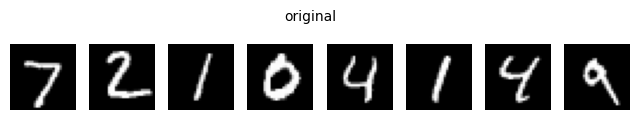

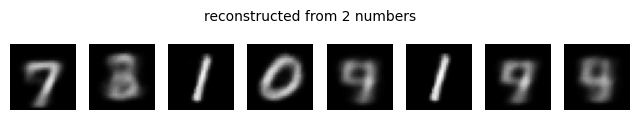

In [2]:
class AE(nn.Module):
    def __init__(self, latent=2):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(784, 256), nn.ReLU(),
                                 nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, latent))
        self.dec = nn.Sequential(nn.Linear(latent, 64), nn.ReLU(),
                                 nn.Linear(64, 256), nn.ReLU(),
                                 nn.Linear(256, 784), nn.Sigmoid())
    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z

def train_ae(model, X, denoise=False, noise=0.5, epochs=8):
    opt = torch.optim.Adam(model.parameters(), 1e-3)
    for ep in range(epochs):
        for (xb,) in DataLoader(TensorDataset(X), batch_size=256, shuffle=True):
            xin = (xb + noise * torch.randn_like(xb)).clamp(0, 1) if denoise else xb
            xhat, _ = model(xin)
            loss = F.binary_cross_entropy(xhat, xb)
            opt.zero_grad(); loss.backward(); opt.step()
    return model

ae = train_ae(AE(latent=2), Xtr[ytr < 9])          # train on digits 0-8 (reused for anomaly)
with torch.no_grad():
    x = Xte[:8]; xhat, _ = ae(x)
show_row(x, "original")
show_row(xhat, "reconstructed from 2 numbers")

## 2. An autoencoder is nonlinear PCA

A **linear** autoencoder (no ReLU) recovers the same subspace as PCA. Add nonlinearity and it
follows curved structure PCA cannot. Compare reconstructions from the same 2-number budget:

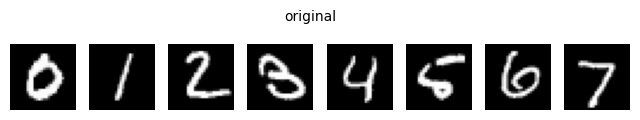

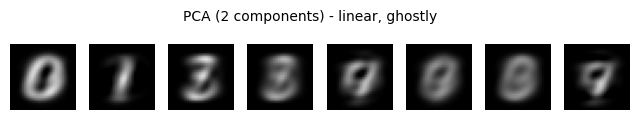

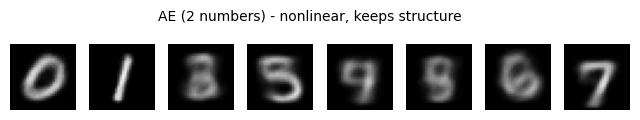

In [3]:
from sklearn.decomposition import PCA
digits = torch.stack([Xte[(yte == d).nonzero()[0, 0]] for d in range(8)])
pca = PCA(n_components=2).fit(Xtr[ytr < 9].numpy())
pca_rec = pca.inverse_transform(pca.transform(digits.numpy()))
with torch.no_grad():
    ae_rec, _ = ae(digits)
show_row(digits, "original")
show_row(pca_rec, "PCA (2 components) - linear, ghostly")
show_row(ae_rec, "AE (2 numbers) - nonlinear, keeps structure")

## 3. Denoising autoencoder

Corrupt the input, train to output the **clean** original. It cannot copy noise, so it must
learn what a digit really is (a cousin of data augmentation).

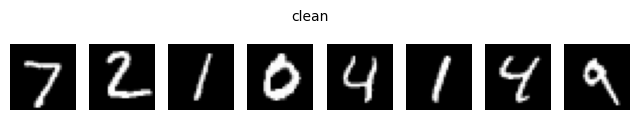

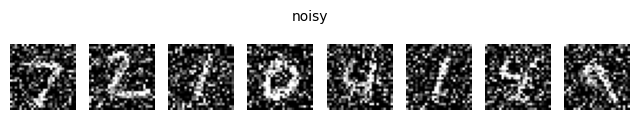

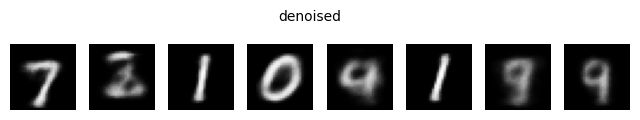

In [4]:
dae = train_ae(AE(latent=32), Xtr, denoise=True)
with torch.no_grad():
    x = Xte[:8]; xn = (x + 0.5 * torch.randn_like(x)).clamp(0, 1); xd, _ = dae(xn)
show_row(x, "clean"); show_row(xn, "noisy"); show_row(xd, "denoised")

## 4. Anomaly detection

Train on **normal data only**; high reconstruction error flags anomalies. It only works when
the anomaly is genuinely different - so we train on 1s and flag 0s.

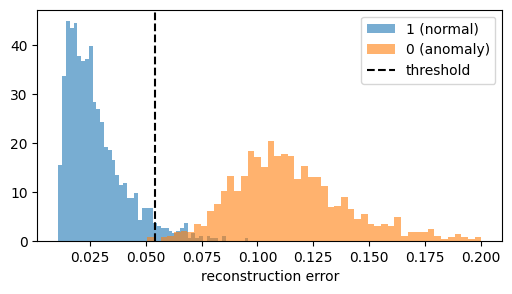

In [5]:
ae1 = train_ae(AE(latent=16), Xtr[ytr == 1])
with torch.no_grad():
    err = ((ae1(Xte)[0] - Xte) ** 2).mean(1).numpy()
plt.figure(figsize=(6, 3))
plt.hist(err[(yte == 1).numpy()], bins=50, alpha=0.6, density=True, label="1 (normal)")
plt.hist(err[(yte == 0).numpy()], bins=50, alpha=0.6, density=True, label="0 (anomaly)")
plt.axvline(np.quantile(err[(yte == 1).numpy()], 0.95), color="k", ls="--", label="threshold")
plt.xlabel("reconstruction error"); plt.legend(); plt.show()

## 5. Why the plain autoencoder cannot generate

To generate, you would draw a random code and decode it. But the AE never made its codes follow
any known distribution - draw `z ~ N(0,I)` and you land off the data manifold.

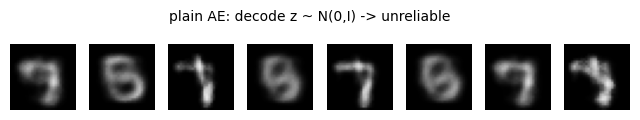

In [6]:
with torch.no_grad():
    samples = ae.dec(torch.randn(8, 2))
show_row(samples, "plain AE: decode z ~ N(0,I) -> unreliable")

## 6. The variational autoencoder (VAE)

The encoder now outputs a **distribution** per input (a mean and a spread), and a **KL term**
pulls every distribution toward `N(0,I)` so the latent space has no holes. The loss is the
**ELBO** = reconstruction - KL. The **reparameterization trick** `z = mu + sigma * eps` (with
`eps ~ N(0,I)`) makes the sampling differentiable so it trains with plain Adam.

In [7]:
class VAE(nn.Module):
    def __init__(self, latent=2):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 64), nn.ReLU())
        self.mu = nn.Linear(64, latent); self.logvar = nn.Linear(64, latent)
        self.dec = nn.Sequential(nn.Linear(latent, 64), nn.ReLU(),
                                 nn.Linear(64, 256), nn.ReLU(),
                                 nn.Linear(256, 784), nn.Sigmoid())
    def encode(self, x):
        h = self.enc(x); return self.mu(h), self.logvar(h)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)   # reparameterization trick
        return self.dec(z), mu, logvar

def train_vae(model, X, epochs=10):
    opt = torch.optim.Adam(model.parameters(), 1e-3)
    for ep in range(epochs):
        for (xb,) in DataLoader(TensorDataset(X), batch_size=256, shuffle=True):
            xhat, mu, logvar = model(xb)
            recon = F.binary_cross_entropy(xhat, xb, reduction="sum") / len(xb)
            kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / len(xb)
            loss = recon + kl
            opt.zero_grad(); loss.backward(); opt.step()
    return model

vae = train_vae(VAE(latent=2), Xtr)

## 7. Generate, sample the grid, interpolate

Sample `z ~ N(0,I)` and decode -> new digits. Sweep a grid of `z` -> a smooth atlas. Interpolate
between two encoded digits -> every step is valid. (Samples are blurry: that is the honest cost
of a 2-D Gaussian VAE.)

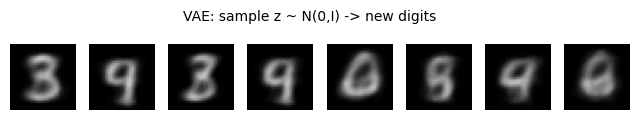

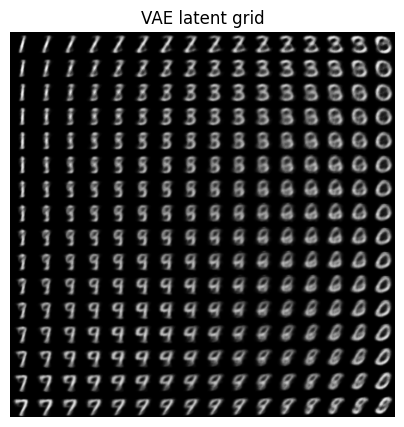

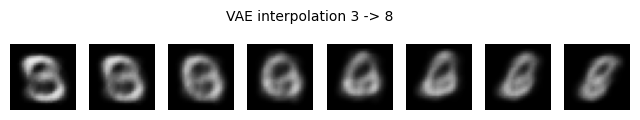

In [8]:
from scipy.stats import norm
with torch.no_grad():
    show_row(vae.dec(torch.randn(8, 2)), "VAE: sample z ~ N(0,I) -> new digits")
    # latent grid
    g = norm.ppf(np.linspace(0.02, 0.98, 16))
    canvas = np.zeros((28 * 16, 28 * 16))
    for i, yi in enumerate(g[::-1]):
        for j, xi in enumerate(g):
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = vae.dec(torch.tensor([[xi, yi]], dtype=torch.float32)).numpy().reshape(28, 28)
    plt.figure(figsize=(5, 5)); plt.imshow(canvas, cmap="gray"); plt.axis("off")
    plt.title("VAE latent grid"); plt.show()
    # interpolation
    i3 = (yte == 3).nonzero()[0, 0]; i8 = (yte == 8).nonzero()[0, 0]
    m3, _ = vae.encode(Xte[i3:i3+1]); m8, _ = vae.encode(Xte[i8:i8+1])
    steps = [vae.dec((1-t)*m3 + t*m8)[0] for t in np.linspace(0, 1, 8)]
show_row(steps, "VAE interpolation 3 -> 8")

## Exercises

1. **Latent size.** Retrain the VAE with `latent=16`. Are the samples sharper? Can you still
   draw a 2-D grid? (No - why?)
2. **The KL knob (beta-VAE).** Multiply the KL term by `beta = 4`. What happens to reconstruction
   quality vs the latent structure?
3. **A fair anomaly test.** Train the anomaly AE on digits 0-8 and try to flag a 9. Why does it
   fail, when 1-vs-0 worked?
4. **Convolutional AE.** Swap the MLP encoder/decoder for `Conv2d` + `ConvTranspose2d` layers.
   Do the reconstructions get sharper?